# Lab 4, Chapter 6

## Ryan Waterman

## 9/26/2025

## Exercise 1

Experiment with the number of hidden neurons in our simple neural network model, as well as the learning rate.

**Set up the model, below:**

In [1]:
%matplotlib inline
import numpy as np
import torch
import torch.optim as optim
import torch.nn as nn

torch.set_printoptions(edgeitems=2, linewidth=75)

In [2]:
t_c = [0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]
t_c = torch.tensor(t_c).unsqueeze(1) # <1>
t_u = torch.tensor(t_u).unsqueeze(1) # <1>

t_u.shape

torch.Size([11, 1])

In [3]:
n_samples = t_u.shape[0]
n_val = int(0.2 * n_samples)

shuffled_indices = torch.randperm(n_samples)

train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

train_indices, val_indices

(tensor([8, 0, 1, 6, 4, 2, 9, 7, 5]), tensor([ 3, 10]))

In [4]:
t_u_train = t_u[train_indices]
t_c_train = t_c[train_indices]

t_u_val = t_u[val_indices]
t_c_val = t_c[val_indices]

t_un_train = 0.1 * t_u_train
t_un_val = 0.1 * t_u_val

In [5]:
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c)**2
    return squared_diffs.mean()

In [6]:
def training_loop(n_epochs, optimizer, model, loss_fn, t_u_train, t_u_val,
                  t_c_train, t_c_val):
    for epoch in range(1, n_epochs + 1):
        t_p_train = model(t_u_train) # <1>
        loss_train = loss_fn(t_p_train, t_c_train)

        t_p_val = model(t_u_val) # <1>
        loss_val = loss_fn(t_p_val, t_c_val)
        
        optimizer.zero_grad()
        loss_train.backward() # <2>
        optimizer.step()

        if epoch == 1 or epoch % 1000 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f},"
                  f" Validation loss {loss_val.item():.4f}")

In [7]:
seq_model = nn.Sequential(
            nn.Linear(1, 13), # <1>
            nn.Tanh(),
            nn.Linear(13, 1)) # <2>
seq_model

Sequential(
  (0): Linear(in_features=1, out_features=13, bias=True)
  (1): Tanh()
  (2): Linear(in_features=13, out_features=1, bias=True)
)

In [8]:
[param.shape for param in seq_model.parameters()]

[torch.Size([13, 1]), torch.Size([13]), torch.Size([1, 13]), torch.Size([1])]

In [9]:
for name, param in seq_model.named_parameters():
    print(name, param.shape)

0.weight torch.Size([13, 1])
0.bias torch.Size([13])
2.weight torch.Size([1, 13])
2.bias torch.Size([1])


In [10]:
from collections import OrderedDict

seq_model = nn.Sequential(OrderedDict([
    ('hidden_linear', nn.Linear(1, 8)),
    ('hidden_activation', nn.Tanh()),
    ('output_linear', nn.Linear(8, 1))
]))

seq_model

Sequential(
  (hidden_linear): Linear(in_features=1, out_features=8, bias=True)
  (hidden_activation): Tanh()
  (output_linear): Linear(in_features=8, out_features=1, bias=True)
)

In [11]:
for name, param in seq_model.named_parameters():
    print(name, param.shape)

hidden_linear.weight torch.Size([8, 1])
hidden_linear.bias torch.Size([8])
output_linear.weight torch.Size([1, 8])
output_linear.bias torch.Size([1])


In [12]:
seq_model.output_linear.bias

Parameter containing:
tensor([-0.3137], requires_grad=True)

In [13]:
optimizer = optim.SGD(seq_model.parameters(), lr=1e-3) # <1>

training_loop(
    n_epochs = 5000, 
    optimizer = optimizer,
    model = seq_model,
    loss_fn = nn.MSELoss(),
    t_u_train = t_un_train,
    t_u_val = t_un_val, 
    t_c_train = t_c_train,
    t_c_val = t_c_val)
    
print('output', seq_model(t_un_val))
print('answer', t_c_val)
print('hidden', seq_model.hidden_linear.weight.grad)

Epoch 1, Training loss 92.6842, Validation loss 610.9580
Epoch 1000, Training loss 3.2130, Validation loss 104.8425
Epoch 2000, Training loss 2.5680, Validation loss 75.6352
Epoch 3000, Training loss 2.4058, Validation loss 63.9210
Epoch 4000, Training loss 2.3168, Validation loss 56.1795
Epoch 5000, Training loss 2.2683, Validation loss 50.8385
output tensor([[18.8679],
        [16.7254]], grad_fn=<AddmmBackward0>)
answer tensor([[28.],
        [21.]])
hidden tensor([[-0.0060],
        [-0.0026],
        [-0.0002],
        [ 0.0112],
        [-0.0113],
        [ 0.0323],
        [ 0.0146],
        [ 0.0095]])


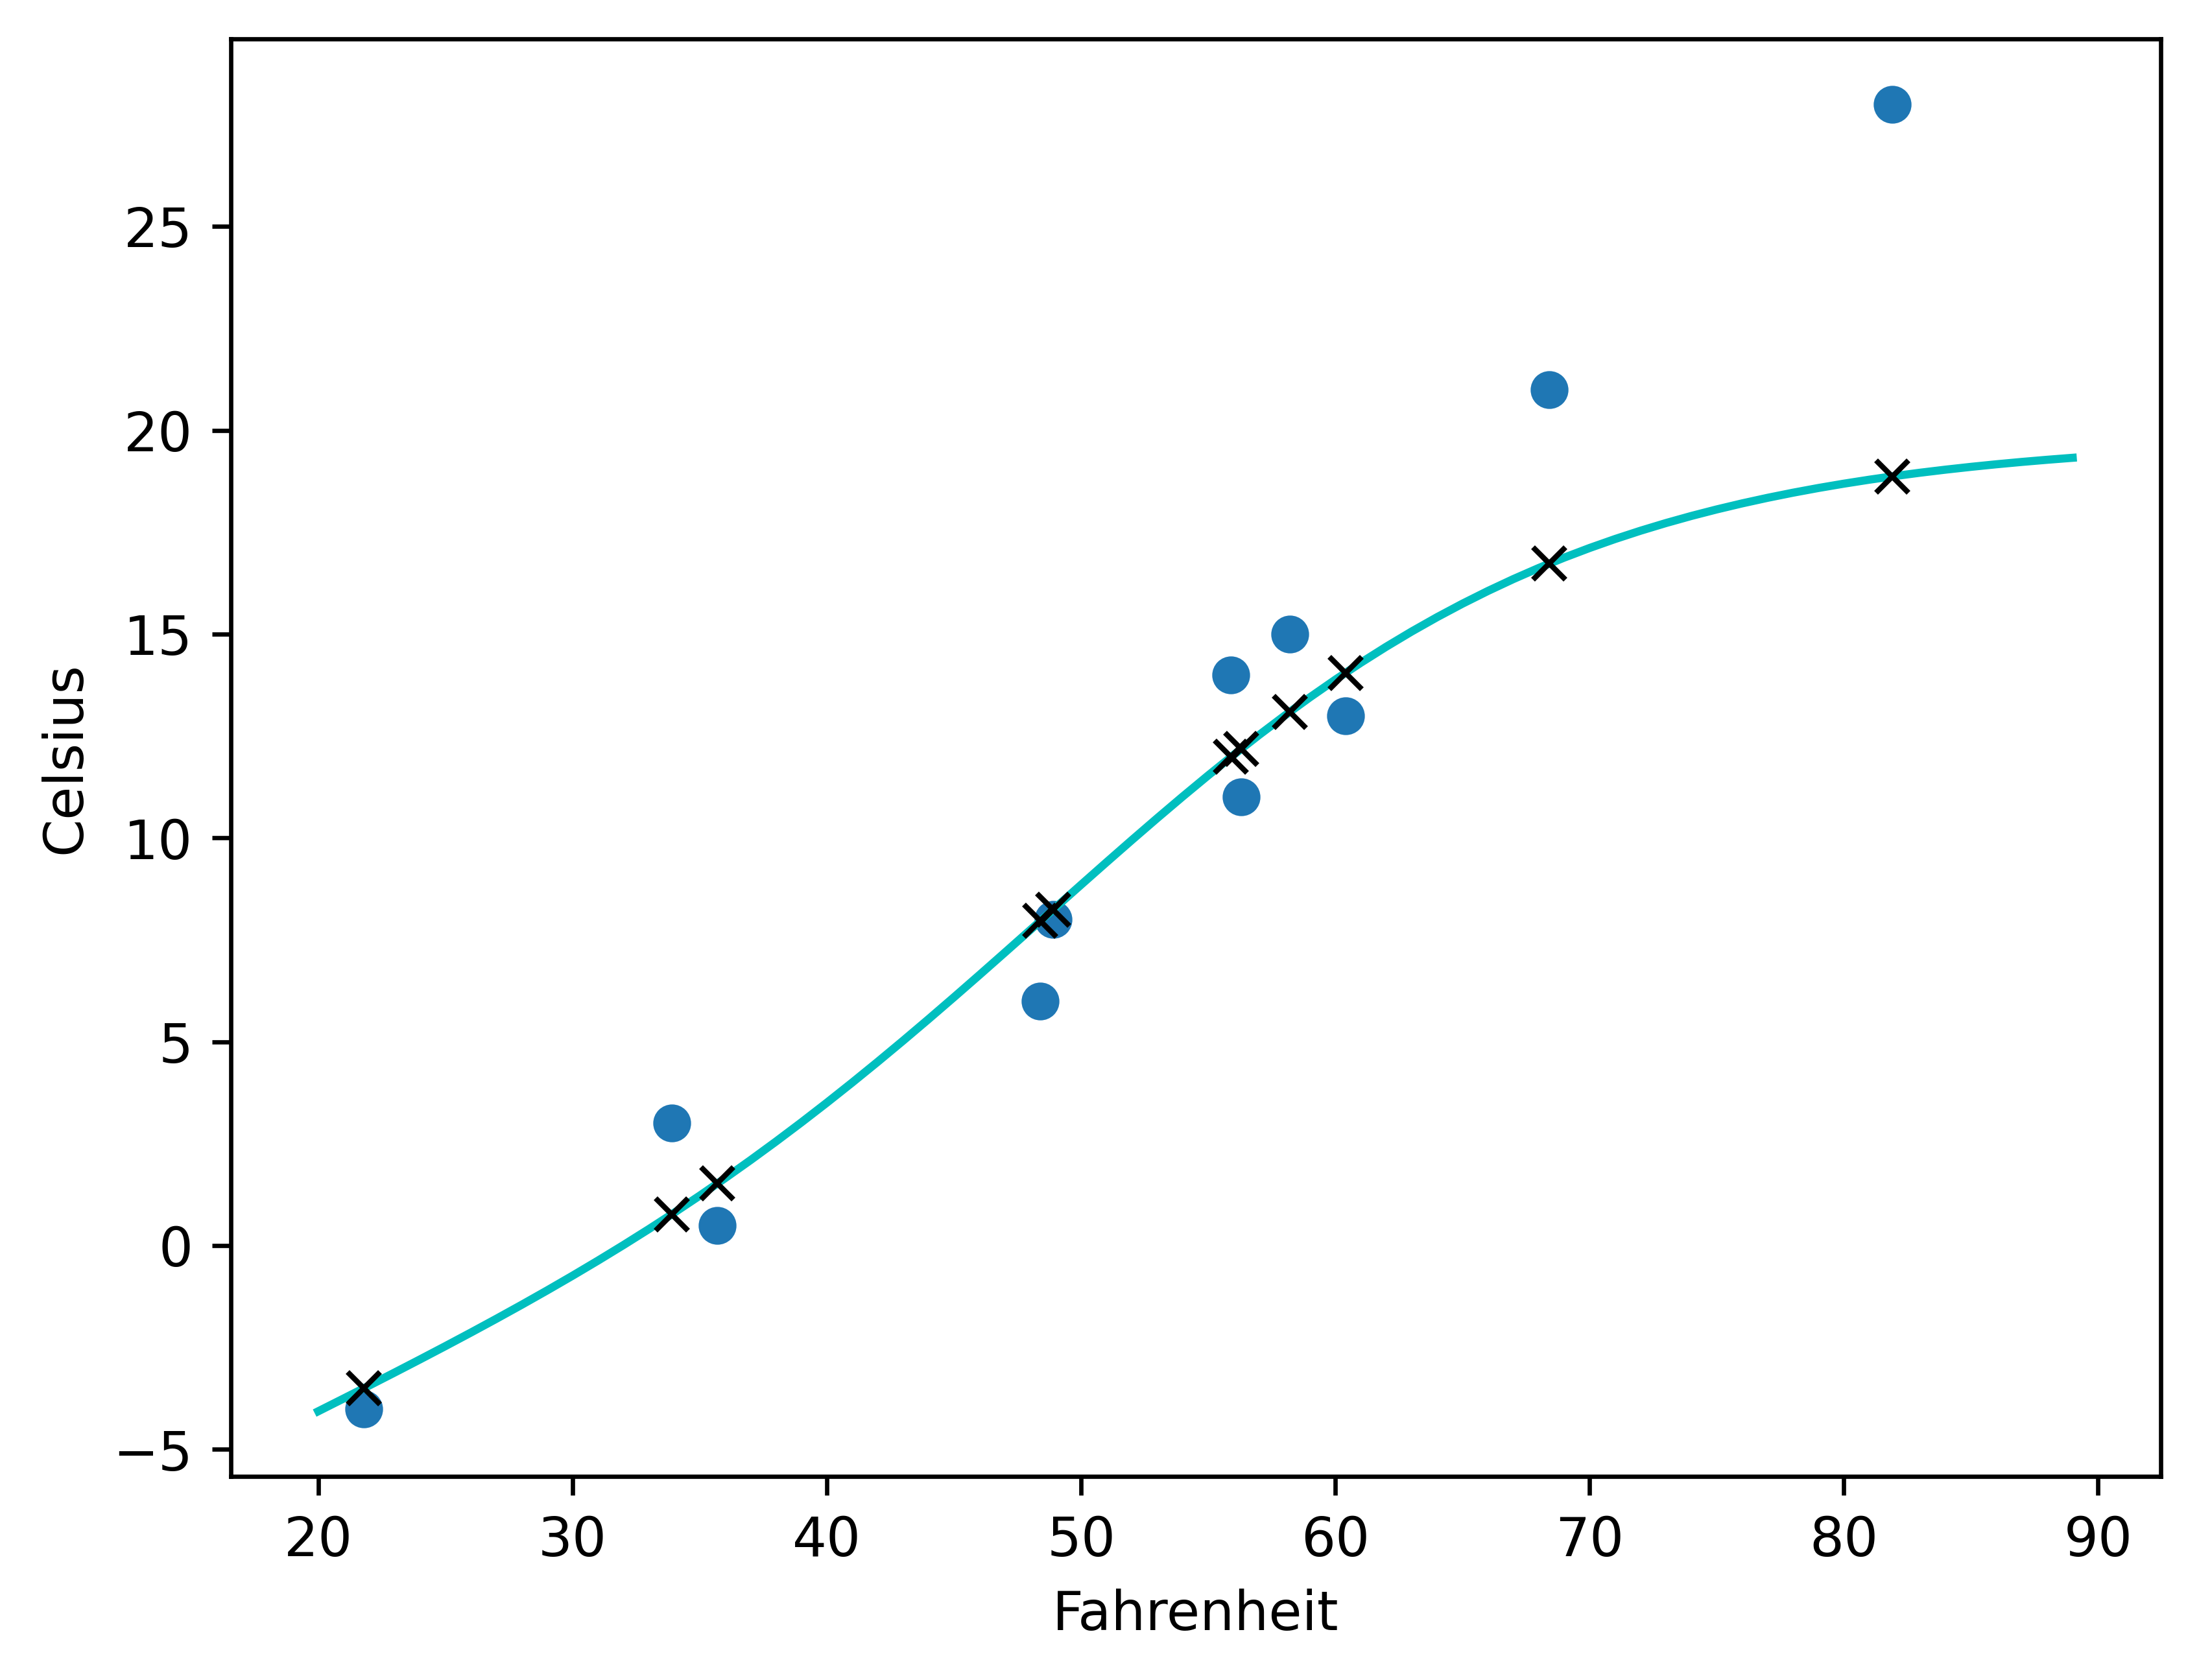

In [14]:
from matplotlib import pyplot as plt

t_range = torch.arange(20., 90.).unsqueeze(1)

fig = plt.figure(dpi=600)
plt.xlabel("Fahrenheit")
plt.ylabel("Celsius")
plt.plot(t_u.numpy(), t_c.numpy(), 'o')
plt.plot(t_range.numpy(), seq_model(0.1 * t_range).detach().numpy(), 'c-')
plt.plot(t_u.numpy(), seq_model(0.1 * t_u).detach().numpy(), 'kx')

**Now that the model has been set up, test with different parameters.**

Epoch 1, Training loss 96.8859, Validation loss 623.6932
Epoch 1000, Training loss 2.8102, Validation loss 53.9950
Epoch 2000, Training loss 2.6071, Validation loss 38.6285
Epoch 3000, Training loss 2.5205, Validation loss 31.9180
Epoch 4000, Training loss 2.4672, Validation loss 27.7536
Epoch 5000, Training loss 2.4295, Validation loss 24.7978
Epoch 1, Training loss 83.8323, Validation loss 581.2708
Epoch 1000, Training loss 12.7175, Validation loss 178.2296
Epoch 2000, Training loss 3.3338, Validation loss 100.6762
Epoch 3000, Training loss 2.5882, Validation loss 75.2229
Epoch 4000, Training loss 2.4419, Validation loss 64.0401
Epoch 5000, Training loss 2.3698, Validation loss 57.2057
Epoch 1, Training loss 111.2850, Validation loss 667.4147
Epoch 1000, Training loss 46.1571, Validation loss 420.5607
Epoch 2000, Training loss 31.5782, Validation loss 323.3815
Epoch 3000, Training loss 27.9575, Validation loss 282.1034
Epoch 4000, Training loss 26.4630, Validation loss 262.5834
Epoch

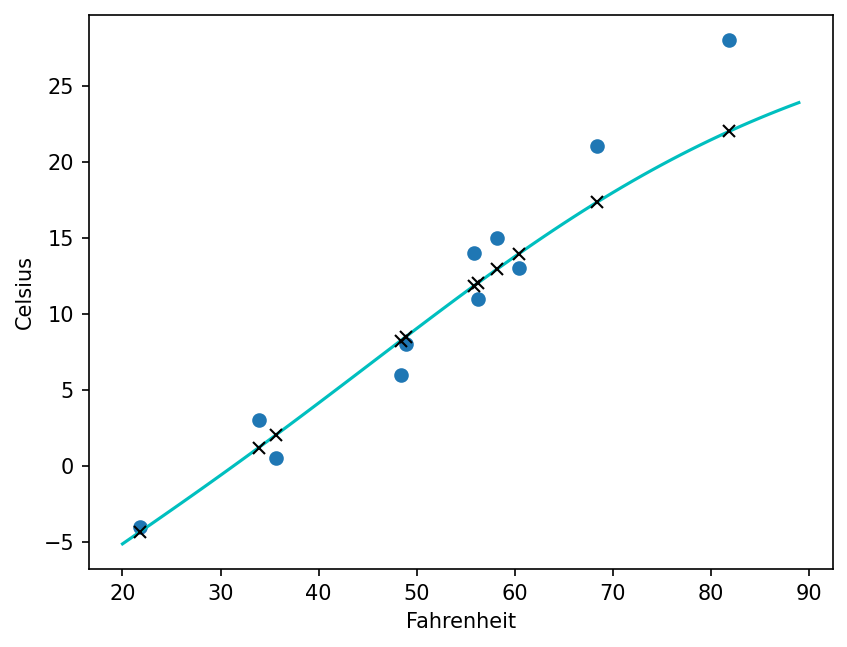

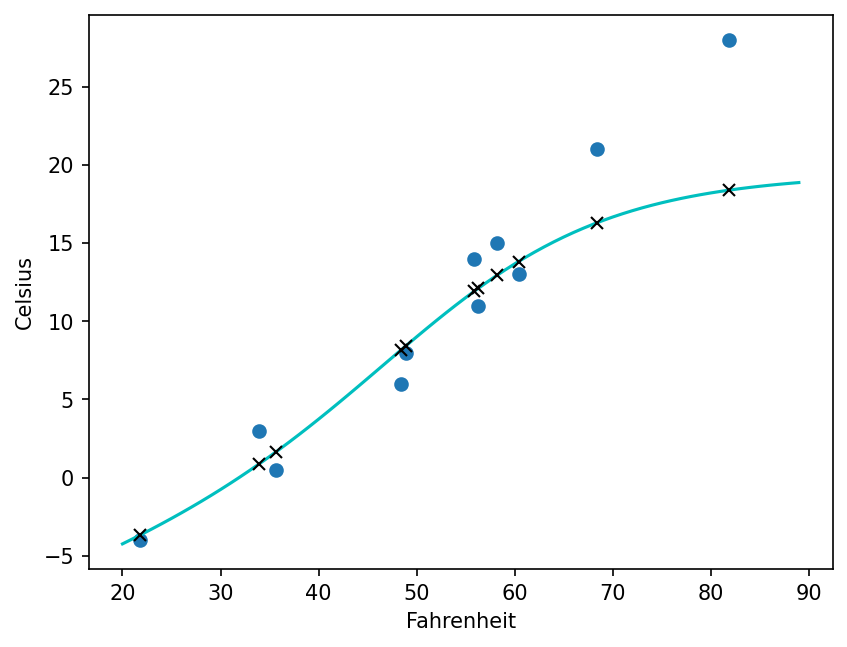

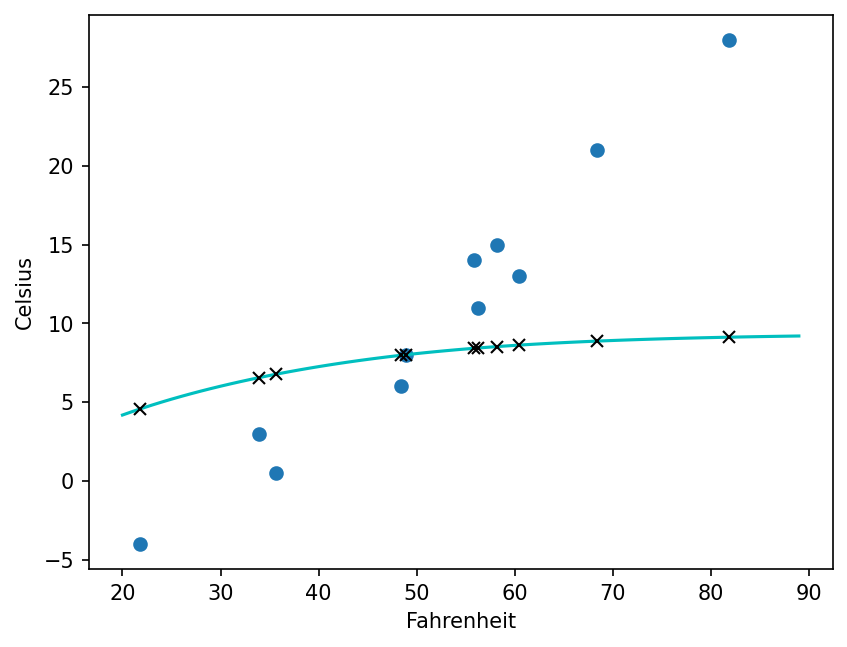

In [15]:
neuron_counts = [100, 15, 50]
lrs = [1e-3, 5e-4, 1e-5]

for nc, lr in zip(neuron_counts, lrs):
    seq_model = nn.Sequential(OrderedDict([
        ('hidden_linear', nn.Linear(1, nc)),
        ('hidden_activation', nn.Tanh()),
        ('output_linear', nn.Linear(nc, 1))
    ])).to('cuda')

    optimizer = optim.SGD(seq_model.parameters(), lr=lr)

    training_loop(
        n_epochs = 5000, 
        optimizer = optimizer,
        model = seq_model,
        loss_fn = nn.MSELoss().to('cuda'),
        t_u_train = t_un_train.to('cuda'),
        t_u_val = t_un_val.to('cuda'), 
        t_c_train = t_c_train.to('cuda'),
        t_c_val = t_c_val.to('cuda'))

    from matplotlib import pyplot as plt

    t_range = torch.arange(20., 90.).unsqueeze(1)

    fig = plt.figure(dpi=150)
    plt.xlabel("Fahrenheit")
    plt.ylabel("Celsius")
    plt.plot(t_u.numpy(), t_c.numpy(), 'o')
    plt.plot(t_range.numpy(), seq_model(0.1 * t_range.to('cuda')).to('cpu').detach().numpy(), 'c-')
    plt.plot(t_u.numpy(), seq_model(0.1 * t_u.to('cuda')).to('cpu').detach().numpy(), 'kx')

### Part A

What changes result in more linear output from the model?

**Growing the number of neurons and increasing the learning rate created a more linear output that fit the data well. Alternatively, a model with 50 neurons and a small learning rate produced a linear output, but it is clear that this was because the model didn't fit to the data.**

### Part B

Can you get the model to obviously overfit the data?

Epoch 1, Training loss 88.7812, Validation loss 597.5264
Epoch 1000, Training loss 3.3435, Validation loss 55.5637
Epoch 2000, Training loss 3.0110, Validation loss 50.4123
Epoch 3000, Training loss 2.7920, Validation loss 45.7860
Epoch 4000, Training loss 2.6205, Validation loss 42.0389
Epoch 5000, Training loss 2.4862, Validation loss 39.1574
Epoch 6000, Training loss 2.3860, Validation loss 37.1042
Epoch 7000, Training loss 2.3102, Validation loss 35.8378
Epoch 8000, Training loss 2.2415, Validation loss 35.2347
Epoch 9000, Training loss 2.1692, Validation loss 35.1964
Epoch 10000, Training loss 2.0860, Validation loss 35.8057
Epoch 11000, Training loss 2.0102, Validation loss 37.5583
Epoch 12000, Training loss 1.9632, Validation loss 41.1272
Epoch 13000, Training loss 1.9215, Validation loss 46.3279
Epoch 14000, Training loss 1.8791, Validation loss 53.2964
Epoch 15000, Training loss 1.8362, Validation loss 61.3217
Epoch 16000, Training loss 1.7952, Validation loss 68.6089
Epoch 17

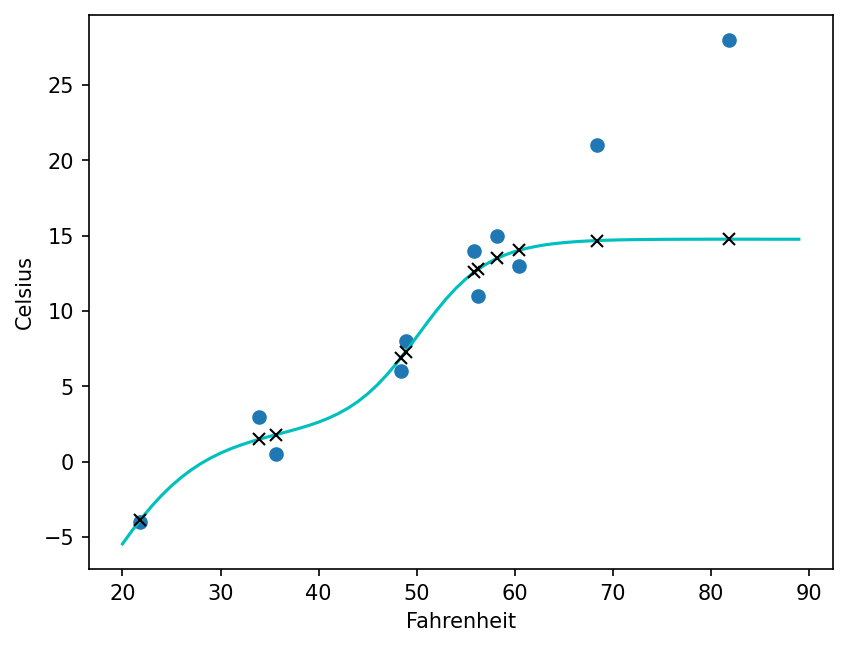

In [16]:
seq_model = nn.Sequential(OrderedDict([
    ('hidden_linear1', nn.Linear(in_features=1, out_features=100)),
    ('hidden_linear2', nn.Linear(in_features=100, out_features=50)),
    ('hidden_activation', nn.Tanh()),
    ('hidden_linear3', nn.Linear(in_features=50, out_features=25)),
    ('hidden_activation', nn.Tanh()),
    ('output_linear', nn.Linear(in_features=25, out_features=1))
]))

#Do this on the GPU to save some time
seq_model.to('cuda')

optimizer = optim.SGD(seq_model.parameters(), lr=2e-4)

training_loop(
    n_epochs = 30000, 
    optimizer = optimizer,
    model = seq_model,
    loss_fn = nn.MSELoss().to('cuda'),
    t_u_train = t_un_train.to('cuda'),
    t_u_val = t_un_val.to('cuda'), 
    t_c_train = t_c_train.to('cuda'),
    t_c_val = t_c_val.to('cuda'))

from matplotlib import pyplot as plt

t_range = torch.arange(20., 90.).unsqueeze(1)

fig = plt.figure(dpi=150)
plt.xlabel("Fahrenheit")
plt.ylabel("Celsius")
plt.plot(t_u.numpy(), t_c.numpy(), 'o')
plt.plot(t_range.numpy(), seq_model(0.1 * t_range.to('cuda')).to('cpu').detach().numpy(), 'c-')
plt.plot(t_u.numpy(), seq_model(0.1 * t_u.to('cuda')).to('cpu').detach().numpy(), 'kx')

**This obviously overfit the data, as the training loss continuously decreased throughout training, but the validation loss plateaued at about 8.8, then eventually started increasing again. This suggests that the model overfit to the training data, and now poorly predicts novel data.**

## Exercise 2

The third-hardest problem in physics is finding a proper wine to celebrate discoveries. Load the wine data from chapter 4, and create a new model with the appropriate number of input parameters.

In [17]:
import pandas as pd

In [18]:
wine_data = pd.read_csv('./data/winequality-white.csv', sep=';')

In [19]:
wine_data.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [20]:
def normalize_column(column):
    col_min = min(column.values)
    col_max = max(column.values)
    normalized_vals = []
    for val in column.values:
        normalized_vals.append((val - col_min) / (col_max - col_min))
    return normalized_vals

In [21]:
for column in wine_data.drop('quality', axis=1, inplace=False).columns:
    wine_data[column] = normalize_column(wine_data[column])

In [36]:
classes = wine_data['quality'].unique()

def one_hot_encode_quality(quality):
    y_vals = []
    for i in range(len(quality)):
        y_vals.append(np.where(classes == quality[i], 1, 0))
    return np.array(y_vals)

quality_data = torch.tensor(one_hot_encode_quality(wine_data['quality'].values))
classes, quality_data.shape

(array([6, 5, 7, 8, 4, 3, 9]), torch.Size([4898, 7]))

In [23]:
n_samples = len(wine_data)
n_val = int(0.2 * n_samples)

shuffled_indices = torch.randperm(n_samples)

train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

len(train_indices), len(val_indices)

(3919, 979)

In [24]:
train_data, val_data = wine_data.iloc[train_indices], wine_data.iloc[val_indices]

In [38]:
X_train = train_data.drop('quality', axis=1, inplace=False)
X_val = val_data.drop('quality', axis=1, inplace=False)
Y_train = quality_data[train_indices]
Y_val = quality_data[val_indices]

Y_train.shape, Y_val.shape

(torch.Size([3919, 7]), torch.Size([979, 7]))

In [26]:
input_feature_count = len(wine_data.drop('quality', axis=1, inplace=False).columns)

In [ ]:
import matplotlib.pyplot as plt

def plot_loss(losses: list, title: str):
    x = np.array([i for i in range(1, len(losses)+1)])
    y = np.array(losses)

    plt.plot(x, y)
    plt.title(title)

In [51]:
def wine_training_loop(n_epochs, optimizer, model, loss_fn, X_train, X_val,
                  Y_train, Y_val):
    train_losses = []
    val_losses = []
    for epoch in range(1, n_epochs + 1):
        p_train = model(X_train) # <1>
        loss_train = loss_fn(p_train, Y_train)
        train_losses.append(loss_train.to('cpu').item())

        p_val = model(X_val) # <1>
        loss_val = loss_fn(p_val, Y_val)
        val_losses.append(loss_val.to('cpu').item())
        
        optimizer.zero_grad()
        loss_train.backward() # <2>
        optimizer.step()

        if epoch == 1 or epoch % 1000 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f},"
                  f" Validation loss {loss_val.item():.4f}")

    plot_loss(train_losses, 'Training Loss')
    plot_loss(val_losses, 'Validation Loss')

c:\Users\water\anaconda3\envs\DSE6211\Lib\site-packages\torch\nn\modules\module.py:1773: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Epoch 1, Training loss 1.7808, Validation loss 1.7828
Epoch 1000, Training loss 1.3080, Validation loss 1.3182
Epoch 2000, Training loss 1.2948, Validation loss 1.3091
Epoch 3000, Training loss 1.2902, Validation loss 1.3053
Epoch 4000, Training loss 1.2867, Validation loss 1.2998
Epoch 5000, Training loss 1.2811, Validation loss 1.2975
Epoch 6000, Training loss 1.2707, Validation loss 1.2890
Epoch 7000, Training loss 1.2465, Validation loss 1.2615
Epoch 8000, Training loss 1.2116, Validation loss 1.2428
Epoch 9000, Training loss 1.1864, Validation loss 1.2184
Epoch 10000, Training loss 1.1720, Validation loss 1.2078
Epoch 11000, Training loss 1.1619, Validation loss 1.1996
Epoch 12000, Training loss 1.1598, Validation loss 1.2006
Epoch 13000, Training loss 1.1487, Validation loss 1.1929
Epoch 14000, Training loss 1.1470, Validation loss 1.1925
Epoch 15000, Training loss 1.1401, Validation loss 1.1869
Epoch 16000, Training loss 1.1367, Validation loss 1.1821
Epoch 17000, Training loss 

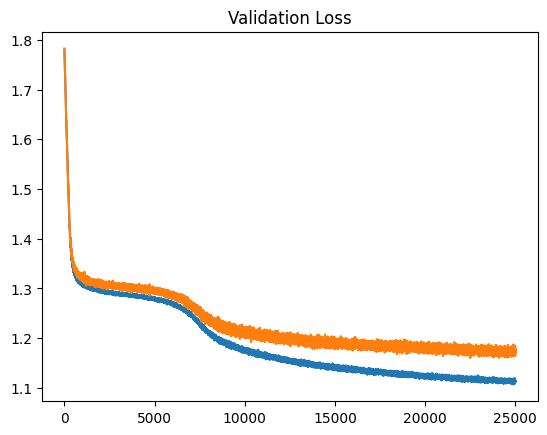

In [88]:
wine_model = nn.Sequential(OrderedDict([
    ('hidden_linear1', nn.Linear(in_features=input_feature_count, out_features=20)),
    ('hidden_linear2', nn.Linear(in_features=20, out_features=50)),
    ('dropout1', nn.Dropout(0.2)),
    ('hidden_linear3', nn.Linear(in_features=50, out_features=40)),
    ('dropout2', nn.Dropout(0.3)),
    ('hidden_linear4', nn.Linear(in_features=40, out_features=20)),
    ('hidden_activation', nn.LeakyReLU()),
    ('hidden_linear6', nn.Linear(in_features=20, out_features=len(classes))),
    ('output_linear', nn.LogSoftmax())
]))

#Do this on the GPU to save some time
wine_model.to('cuda')

optimizer = optim.SGD(wine_model.parameters(), lr=5e-3)

wine_training_loop(
    n_epochs = 25000, 
    optimizer = optimizer,
    model = wine_model,
    loss_fn = nn.CrossEntropyLoss().to('cuda'),
    X_train = torch.tensor(X_train.values).to(torch.float).to('cuda'),
    X_val = torch.tensor(X_val.values).to(torch.float).to('cuda'), 
    Y_train = Y_train.to(torch.float).to('cuda'),
    Y_val = Y_val.to(torch.float).to('cuda')
    )


**Have the model predict on the validation data and determine the accuracy.**

In [89]:
val_total = len(val_indices)
correct_preds = 0
for idx in range(val_total):
    probs = torch.exp(wine_model(torch.tensor(X_val.iloc[idx].values).to(torch.float).to('cuda')))
    pred = torch.argmax(probs).to('cpu').item()
    true_val = np.where(Y_val[idx].numpy()==1)[0][0]
    if pred == true_val:
        correct_preds+=1

print(f'Accuracy: {(correct_preds/val_total)*100:.2f}')

Accuracy: 50.36


### Part A

How  long  does  it  take  to  train  compared  to  the  temperature  data  we  have been using?

**The training time increased dramatically, but that is because I grew the model size and input data size. As the complexity of the model and input data size grows, the training time grows.**

### Part B

Can you explain what factors contribute to the training times?

**I think a good analogy for this would be Big O notation in algorithm programming. Time complexity of functions described by Big O notation indicate the rate at which time is added by scaling the number of iterations of the algorithm. In this case, the forward pass is dependent on the data and model size, but training also requires backpropagation. This means that for a given model size and dataset size, the model will need to make 2 passes through the network, with the backprop adding additional compute to calculate the gradients of the weights and biases. I have seen papers that say neural networks have a time complexity of O(n^4), as a result of having L layers of size M with n input features and b batches, which seems reasonable to me.**

### Part C

Can you get the loss to decrease while training on this dataset?

**Yes, I did get the loss to decrease, but my final prediction accuracy is essentially just randomly guessing. This is likely because I have no clue what I am doing and I came up with an arbitrary model architecture.**

### Part D

How would you go about graphing this dataset?

**As seen above, I stored the losses over the training cycle, then plotted the training and validation losses. This graph is an indicator of how well the model learning the data, and whether or not it is overfitting. In this case, there is an indication that the model was overfitting, as there was a growing disparity between the training and validation losses.**